# **Investigating Netflix Movies**

**Netflix**! What started in 1997 as a DVD rental service has since exploded into one of the largest entertainment and media companies.

Given the large number of movies and series available on the platform, it is a perfect opportunity to flex your exploratory data analysis skills and dive into the entertainment industry.

You work for a production company that specializes in nostalgic styles. You want to do some research on movies released in the 1990's. You'll delve into Netflix data and perform exploratory data analysis to better understand this awesome movie decade!

You have been supplied with the dataset `netflix_data.csv`, along with the following table detailing the column names and descriptions.

**The Data** - `netflix_data.csv`
| Column | Description |
|--------|-------------|
| `show_id` | The ID of the show |
| `type` | Type of show |
| `title` | Title of the show |
| `director` | Director of the show |
| `cast` | Cast of the show |
| `country` | Country of origin |
| `date_added` | Date added to Netflix |
| `release_year` | Year of Netflix release |
| `duration` | Duration of the show in minutes |
| `description` | Description of the show |
| `genre` | Show genre |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

netflix_df = pd.read_csv("netflix_data.csv")

is_1990s_movie = (netflix_df['release_year'].between(1990, 1999)) & (netflix_df['type'] == 'Movie')
netflix_df_1990 = netflix_df[is_1990s_movie]

print("1990s Movies Filtered")

1990s Movies Filtered


### Calculating Movie Durations and Distribution
We calculate the statistical mode to find the most frequent duration and plot a histogram to view the distribution.

The most frequent movie duration in the 1990s was 94 minutes


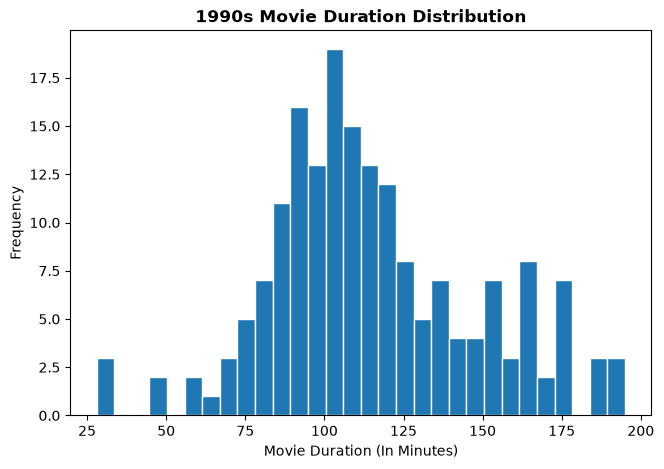

In [2]:
duration = netflix_df_1990['duration'].mode()[0]
print(f"The most frequent movie duration in the 1990s was {duration} minutes")

plt.figure(figsize=(7.5, 5))
plt.hist(netflix_df_1990['duration'], bins=30, edgecolor='white')
plt.title("1990s Movie Duration Distribution", fontweight='bold')
plt.xlabel("Movie Duration (In Minutes)")
plt.ylabel("Frequency")
plt.show()

### Counting Short Action Movies
We filter the action films under 90 minutes and count the rows in the filtered dataset.

In [3]:
is_short_action = (netflix_df_1990['duration'] < 90) & (netflix_df_1990['genre'] == 'Action')
netflix_df_short_action = netflix_df_1990[is_short_action]

short_movie_count = netflix_df_short_action.shape[0]
print(f"The number of short action movies in the 1990s was {short_movie_count}")

The number of short action movies in the 1990s was 7


### Determining Top Film-Producing Countries
We compute the value counts of the country to identify which ones produced the most movies in the dataset.

In [4]:
netflix_df_top = netflix_df_1990["country"].value_counts().head(5)
print("Top 5 Film-Producing Countries (1990s)")
print(netflix_df_top.to_string(header=False))

Top 5 Film-Producing Countries (1990s)
United States     99
India             34
United Kingdom    17
Hong Kong         11
France             5


### Calculating Movie Duration Trends
We group the data by release year to calculate the mean duration and see how average movie durations changes from 1990 to 1999.

Annual Average Duration Trend
1990    117.428571
1991     93.500000
1992    104.000000
1993    120.000000
1994    128.428571
1995    116.437500
1996    120.133333
1997    116.961538
1998    109.884615
1999    121.884615


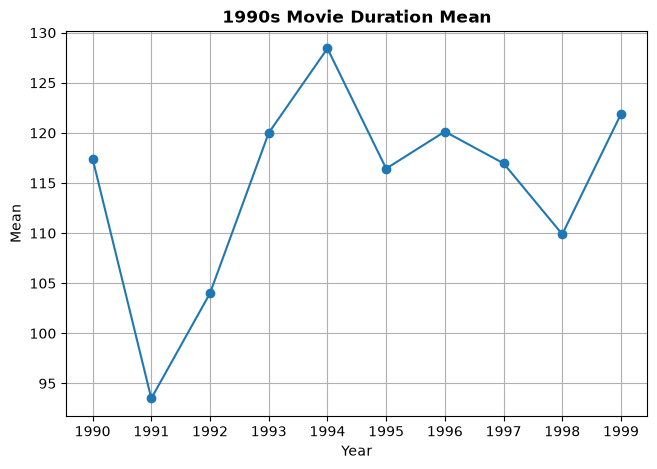

In [ ]:
netflix_df_trend = netflix_df_1990.groupby("release_year")["duration"].mean()

print("Annual Average Duration Trend")
print(netflix_df_trend.to_string(header=False))

plt.figure(figsize=(7.5, 5))
plt.plot(range(1990, 2000), netflix_df_trend, marker='o')
plt.title("1990s Average Movie Duration", fontweight='bold')
plt.xlabel("Year")
plt.xticks(range(1990, 2000))
plt.ylabel("Mean")
plt.grid(True)
plt.show()

### Conlusion
The results of our analysis gave us valuable insights about the movies in the 1990s.

* The most frequent movie duration was 94 minutes, which is a standard runtime.
* The number of short action movies was only 7, implying that short runtime within this genre were quite rare.
* The film industry was dominated by the United States, followed by India and the United Kingdom.
* The highest average movie duration was 128 minutes in 1994, while the lowest average was 94 minutes in 1991.